In [1]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
from src.data_load import getDataFrame


In [2]:
df_clean = getDataFrame()
df_clean.head()

,accidentDate,accidentTime,accidentDay,settlementType,settlement,district,streetType,streetName,houseNumber,locationComments,...,injuryStatusParticipant4,injuryStatusParticipant5,injuryStatusParticipant6,injuryStatusParticipant7,injuryStatusParticipant8,injuryStatusParticipant9,injuryStatusParticipant10,injuryStatusParticipant11,latitude,longitude
0,2024-01-20,1:08:00 PM,субота,місто,Львів,Сихівський,вулиця,Стрийська,45,NaN,...,легко травмований,легко травмований,NaN,NaN,NaN,NaN,NaN,NaN,49.806862,24.019042
1,2024-01-20,1:05:00 PM,субота,місто,Львів,Франківський,вулиця,Наукова,55,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,49.805076,23.985938
2,2024-01-23,8:31:00 AM,вівторок,місто,Львів,Шевченківський,вулиця,"Мазепи І., гетьм.",1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,49.869788,24.027228
3,2024-01-23,9:45:00 AM,вівторок,місто,Львів,Сихівський,вулиця,Демнянська,4,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,49.799460,24.030849
4,2024-02-16,10:20:00 AM,п'ятниця,місто,Львів,Галицький,вулиця,Папарівка,14,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,49.851678,24.037018


In [3]:
print("--- ТОП-5 причин ДТП ---")
df_clean['mainAccidentCause'].value_counts().head(5)

--- ТОП-5 причин ДТП ---


mainAccidentCause
порушення правил маневрування                    241
порушення правил проїзду пішохідних переходів    119
перевищення безпечної швидкості                   68
порушення правил проїзду перехресть               58
недодержання дистанції                            49
Name: count, dtype: int64

In [4]:
print("--- Найбільш аварійні вулиці ---")
df_clean['streetName'].dropna().value_counts().head(10)

--- Найбільш аварійні вулиці ---


streetName
Городоцька                 66
Шевченка Т.                42
Зелена                     39
Стрийська                  28
Липинського В.             27
Личаківська                26
Чорновола В., просп.       25
Червоної Калини, просп.    22
Кульпарківська             21
Пасічна                    21
Name: count, dtype: int64

In [5]:
X = df_clean[['latitude', 'longitude']]
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

df_clean = df_clean.copy()
df_clean['cluster'] = kmeans.fit_predict(X)

In [6]:
for i, center in enumerate(kmeans.cluster_centers_):
    print(f"Кластер {i}: {center[0]:.4f}, {center[1]:.4f}")

Кластер 0: 49.8253, 23.9892
Кластер 1: 49.8379, 24.0929
Кластер 2: 49.8029, 24.0472
Кластер 3: 49.8564, 23.9378
Кластер 4: 49.8519, 24.0308


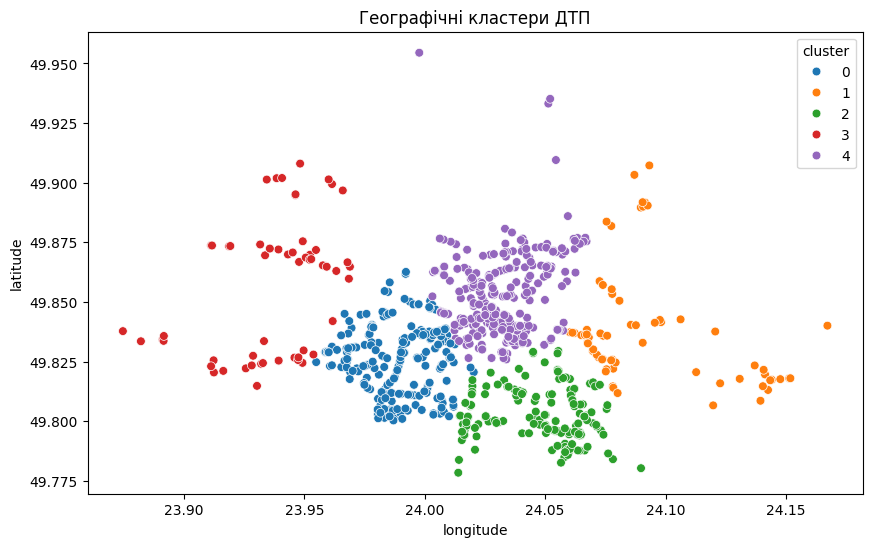

In [7]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df_clean,
    x='longitude',
    y='latitude',
    hue='cluster',
    palette='tab10',
    s=40
)
plt.title("Географічні кластери ДТП")
plt.show()

In [9]:
import os

os.makedirs("../reports", exist_ok=True)
df_clean.to_csv("../reports/clustered_data.csv", index=False)

print("Clustered data saved.")

Clustered data saved.
